# Stress Concentration Near a Notch
## Finite Element Simulation

This notebook builds a minimal finite element simulation of a notched rectangular bar under tension.

#### Goal
To reproduce the qualtitative bheavior shown both lines of stress diagrams and show what "stress risers" actually mean.  Stress trajectories bend around the notch and become concentrated near the notch tip.

#### Approach
Solve the 2D linear elasticity problem using constant-strain triangular elements.

## Mechanical Equilibrium as Local Force Balance

The bar is being pulled slowly, so we treat the problem as **static**. That means the material is not accelerating. Every small piece of the bar must therefore satisfy force balance.

For an ordinary particle, Newton’s second law is

$$
\mathbf{F}=m\mathbf{a}.
$$

In static equilibrium,

$$
\mathbf{a}=\mathbf{0},
$$

so

$$
\mathbf{F}=\mathbf{0}.
$$

For a continuous solid, we apply the same idea to a small material region. The forces acting on that region come mainly from stresses on its boundary. Stress is force per unit area, so the stress tensor $\boldsymbol{\sigma}$ tells us how much force neighboring material applies across an internal surface.

For a small volume element, the net internal force density is given by the divergence of the stress tensor:

$$
\nabla \cdot \boldsymbol{\sigma}.
$$

Therefore, local force balance requires

$$
\nabla \cdot \boldsymbol{\sigma} = \mathbf{0}.
$$

This is the continuum version of

$$
\sum \mathbf{F}=\mathbf{0}.
$$

In component form, for a 2D body,

$$
\nabla \cdot \boldsymbol{\sigma}
=
\begin{bmatrix}
\frac{\partial \sigma_{xx}}{\partial x}
+
\frac{\partial \sigma_{xy}}{\partial y}
\\[6pt]
\frac{\partial \sigma_{yx}}{\partial x}
+
\frac{\partial \sigma_{yy}}{\partial y}
\end{bmatrix}
=
\begin{bmatrix}
0\\
0
\end{bmatrix}.
$$

Since ordinary elastic stress tensors are symmetric,

$$
\sigma_{xy}=\sigma_{yx}.
$$

So the two equilibrium equations are

$$
\frac{\partial \sigma_{xx}}{\partial x}
+
\frac{\partial \sigma_{xy}}{\partial y}
=0,
$$

$$
\frac{\partial \sigma_{xy}}{\partial x}
+
\frac{\partial \sigma_{yy}}{\partial y}
=0.
$$

These equations say that the stress field cannot vary arbitrarily. If the stress increases in one direction, other stress components must adjust so that every small piece of material remains in force balance.

The notch matters because it changes the boundary of the solid. The material near the notch surface is traction-free, but the far left and right sides are pulled in tension. The stress field must satisfy both the boundary conditions and local equilibrium. The result is that the stress trajectories bend around the notch and crowd near the notch tip.

The governing equilibrium equation is
$$
\nabla \cdot \boldsymbol{\sigma} = \mathbf{0}.
$$

The stress is related to strain by the plane-stress constitutive law
$$
\boldsymbol{\sigma}
=
\mathbf{D}\boldsymbol{\varepsilon}.
$$


nodes = 9612
triangles = 18732
dofs = 19224


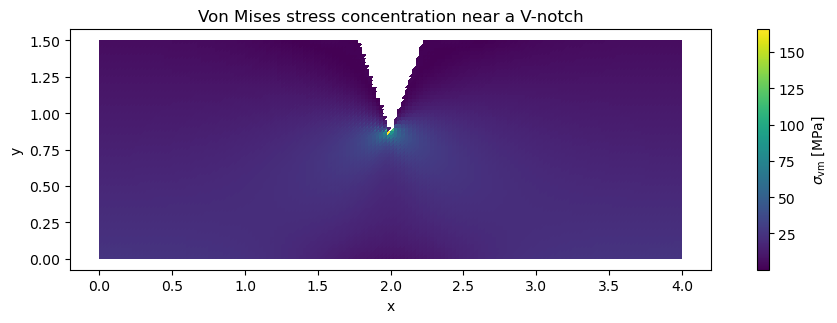

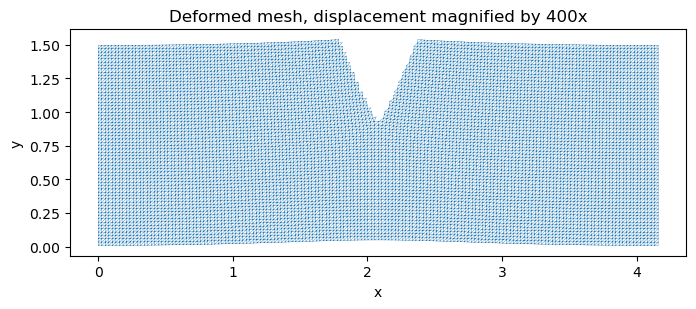

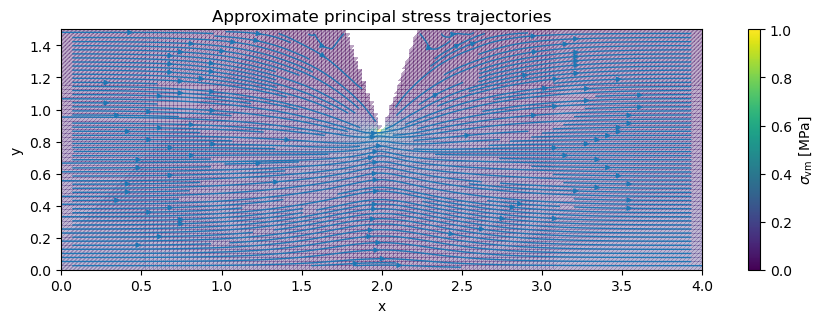

Nominal stress estimate: 20.000 MPa
Max von Mises stress:     165.478 MPa
Approximate Kt_vm:        8.274


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.interpolate import griddata

def get_vonmises_stress_2D(sigma_tensor):
    
# ------------------------------------------------------------
# 1. Geometry and mesh
# ------------------------------------------------------------

L = 4.0          # bar length
H = 1.5          # bar height

Nx = 161
Ny = 61

x = np.linspace(0.0, L, Nx)
y = np.linspace(0.0, H, Ny)

X, Y = np.meshgrid(x, y, indexing="xy")
points_full = np.column_stack([X.ravel(), Y.ravel()])


# Notch geometry: V-notch cut from the top edge
notch_center = L / 2
notch_width = 0.45
notch_depth = 0.65

def inside_notch_region(x, y):
    dx = np.abs(x - notch_center)
    half_w = notch_width / 2

    inside_width = dx <= half_w
    notch_boundary_y = H - notch_depth + notch_depth * dx / half_w

    return inside_width & (y >= notch_boundary_y)


# Structured triangular mesh before removing notch
def node_id(i, j):
    return j * Nx + i

triangles_full = []

for j in range(Ny - 1):
    for i in range(Nx - 1):
        n00 = node_id(i, j)
        n10 = node_id(i + 1, j)
        n01 = node_id(i, j + 1)
        n11 = node_id(i + 1, j + 1)

        triangles_full.append([n00, n10, n11])
        triangles_full.append([n00, n11, n01])

triangles_full = np.array(triangles_full, dtype=int)


# Remove triangles whose centroids lie inside the notch
centroids = points_full[triangles_full].mean(axis=1)
keep_tri = ~inside_notch_region(centroids[:, 0], centroids[:, 1])

triangles_kept = triangles_full[keep_tri]

# Remove unused nodes and reindex
used_nodes = np.unique(triangles_kept.ravel())
old_to_new = -np.ones(points_full.shape[0], dtype=int)
old_to_new[used_nodes] = np.arange(len(used_nodes))

points = points_full[used_nodes]
triangles = old_to_new[triangles_kept]

n_nodes = points.shape[0]
n_dofs = 2 * n_nodes

print(f"nodes = {n_nodes}")
print(f"triangles = {len(triangles)}")
print(f"dofs = {n_dofs}")


# ------------------------------------------------------------
# 2. Plane-stress material law
# ------------------------------------------------------------

E = 200.0e9       # Pa, representative steel-like modulus
nu = 0.30

D = (E / (1.0 - nu**2)) * np.array([
    [1.0, nu, 0.0],
    [nu, 1.0, 0.0],
    [0.0, 0.0, (1.0 - nu) / 2.0]
])


# ------------------------------------------------------------
# 3. Constant-strain triangle element
# ------------------------------------------------------------

def cst_B_matrix(coords):
    """
    Constant strain triangle.

    coords has shape (3, 2):
        [[x1, y1],
         [x2, y2],
         [x3, y3]]

    Returns:
        B: strain-displacement matrix
        A: triangle area
    """

    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]

    A = 0.5 * np.linalg.det(np.array([
        [1.0, x1, y1],
        [1.0, x2, y2],
        [1.0, x3, y3]
    ]))

    if A <= 0:
        raise ValueError("Triangle has nonpositive area. Check node ordering.")

    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2

    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1

    B = (1.0 / (2.0 * A)) * np.array([
        [b1, 0.0, b2, 0.0, b3, 0.0],
        [0.0, c1, 0.0, c2, 0.0, c3],
        [c1, b1, c2, b2, c3, b3]
    ])

    return B, A


# ------------------------------------------------------------
# 4. Assemble global stiffness matrix
# ------------------------------------------------------------

K = lil_matrix((n_dofs, n_dofs))
thickness = 1.0

for tri in triangles:
    coords = points[tri]
    B, A = cst_B_matrix(coords)

    Ke = thickness * A * (B.T @ D @ B)

    dofs = np.array([
        2 * tri[0],     2 * tri[0] + 1,
        2 * tri[1],     2 * tri[1] + 1,
        2 * tri[2],     2 * tri[2] + 1
    ])

    for a in range(6):
        for b in range(6):
            K[dofs[a], dofs[b]] += Ke[a, b]

K = csr_matrix(K)


# ------------------------------------------------------------
# 5. Boundary conditions
# ------------------------------------------------------------

u = np.zeros(n_dofs)
f = np.zeros(n_dofs)

tol = 1e-12

left_nodes = np.where(np.isclose(points[:, 0], 0.0, atol=tol))[0]
right_nodes = np.where(np.isclose(points[:, 0], L, atol=tol))[0]

Delta = 1.0e-4 * L   # imposed tensile displacement

fixed_dofs = []
fixed_values = []

# Left edge: u_x = 0
for n in left_nodes:
    fixed_dofs.append(2 * n)
    fixed_values.append(0.0)

# Right edge: u_x = Delta
for n in right_nodes:
    fixed_dofs.append(2 * n)
    fixed_values.append(Delta)

# Remove rigid vertical translation:
# fix u_y at one left-edge node near mid-height
left_mid = left_nodes[np.argmin(np.abs(points[left_nodes, 1] - H / 2))]
fixed_dofs.append(2 * left_mid + 1)
fixed_values.append(0.0)

fixed_dofs = np.array(fixed_dofs, dtype=int)
fixed_values = np.array(fixed_values)

all_dofs = np.arange(n_dofs)
free_dofs = np.setdiff1d(all_dofs, fixed_dofs)

u[fixed_dofs] = fixed_values

# Reduced system:
# K_ff u_f = f_f - K_fc u_c
K_ff = K[free_dofs][:, free_dofs]
K_fc = K[free_dofs][:, fixed_dofs]

rhs = f[free_dofs] - K_fc @ u[fixed_dofs]

u[free_dofs] = spsolve(K_ff, rhs)


# ------------------------------------------------------------
# 6. Compute element stresses
# ------------------------------------------------------------

elem_centroids = []
elem_sigma = []
elem_vm = []
elem_principal_dir = []

for tri in triangles:
    coords = points[tri]
    B, A = cst_B_matrix(coords)

    dofs = np.array([
        2 * tri[0],     2 * tri[0] + 1,
        2 * tri[1],     2 * tri[1] + 1,
        2 * tri[2],     2 * tri[2] + 1
    ])

    ue = u[dofs]
    strain = B @ ue
    sigma = D @ strain

    sxx, syy, sxy = sigma

    sigma_tensor = np.array([
        [sxx, sxy],
        [sxy, syy]
    ])

    eigvals, eigvecs = np.linalg.eigh(sigma_tensor)
    idx = np.argmax(eigvals)
    v1 = eigvecs[:, idx]

    # orient roughly in +x direction for cleaner streamlines
    if v1[0] < 0:
        v1 = -v1

    sigma_vm = np.sqrt(sxx**2 - sxx * syy + syy**2 + 3.0 * sxy**2)

    elem_centroids.append(coords.mean(axis=0))
    elem_sigma.append(sigma)
    elem_vm.append(sigma_vm)
    elem_principal_dir.append(v1)

elem_centroids = np.array(elem_centroids)
elem_sigma = np.array(elem_sigma)
elem_vm = np.array(elem_vm)
elem_principal_dir = np.array(elem_principal_dir)


# ------------------------------------------------------------
# 7. Plot von Mises stress field
# ------------------------------------------------------------

plt.figure(figsize=(10, 3.2))

plt.tripcolor(
    points[:, 0],
    points[:, 1],
    triangles,
    facecolors=elem_vm / 1e6,
    shading="flat"
)

plt.gca().set_aspect("equal")
plt.colorbar(label=r"$\sigma_\mathrm{vm}$ [MPa]")
plt.title("Von Mises stress concentration near a V-notch")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Plot deformed mesh
# ------------------------------------------------------------

scale = 400.0

points_def = points + scale * u.reshape((-1, 2))

plt.figure(figsize=(10, 3.2))

plt.triplot(
    points_def[:, 0],
    points_def[:, 1],
    triangles,
    linewidth=0.25
)

plt.gca().set_aspect("equal")
plt.title(f"Deformed mesh, displacement magnified by {scale:g}x")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Principal stress trajectories
# ------------------------------------------------------------

gx = np.linspace(0.0, L, 300)
gy = np.linspace(0.0, H, 120)
GX, GY = np.meshgrid(gx, gy)

inside_domain = ~inside_notch_region(GX, GY)

Vx = griddata(
    elem_centroids,
    elem_principal_dir[:, 0],
    (GX, GY),
    method="linear"
)

Vy = griddata(
    elem_centroids,
    elem_principal_dir[:, 1],
    (GX, GY),
    method="linear"
)

VM = griddata(
    elem_centroids,
    elem_vm,
    (GX, GY),
    method="linear"
)

Vx[~inside_domain] = np.nan
Vy[~inside_domain] = np.nan
VM[~inside_domain] = np.nan

speed = np.sqrt(Vx**2 + Vy**2)

plt.figure(figsize=(10, 3.2))

plt.tripcolor(
    points[:, 0],
    points[:, 1],
    triangles,
    facecolors=elem_vm / 1e6,
    shading="flat",
    alpha=0.35
)

plt.streamplot(
    GX,
    GY,
    Vx,
    Vy,
    density=2.0,
    linewidth=1.0,
    arrowsize=0.7
)

plt.gca().set_aspect("equal")
plt.colorbar(label=r"$\sigma_\mathrm{vm}$ [MPa]")
plt.title("Approximate principal stress trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Stress concentration estimate
# ------------------------------------------------------------

nominal_strain = Delta / L
nominal_stress = E * nominal_strain

Kt_vm = np.nanmax(elem_vm) / nominal_stress

print(f"Nominal stress estimate: {nominal_stress / 1e6:.3f} MPa")
print(f"Max von Mises stress:     {np.nanmax(elem_vm) / 1e6:.3f} MPa")
print(f"Approximate Kt_vm:        {Kt_vm:.3f}")